# pyinfluence: a tour of training-data attribution

This notebook walks through the figures `pyinfluence` exposes, in the order a
typical workflow would use them.

Each section answers one question:

| Question | Figure |
|---|---|
| Which training samples look mislabeled? | `plot_self_influence` |
| Why did the model predict *this* for *that* test point? | `plot_top_influencers` |
| Are the influence scores actually meaningful? | `plot_removal_curve` |
| Are some subgroups systematically harmful? | `plot_by_group` |
| Do two methods agree? | `plot_method_comparison` |
| Is the ranking stable under resampling? | `plot_top_k_stability` |
| What does this all look like at a glance? | `report` |

We use a synthetic regression problem so the **ground truth** of which samples
are corrupted is known. The last section runs `report()` on the real `breast_cancer` dataset to close the loop.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pyinfluence import (
    BootstrapInfluence,
    InfluenceFunctions,
    LOOInfluence,
    find_mislabeled,
    influence,
    removal_curve,
    self_influence,
)
from pyinfluence import viz

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
RNG = np.random.default_rng(0)

## 1. The scenario: a regression dataset with a known label bug

We simulate the kind of data-quality incident pyinfluence is built for. There
are 200 training samples, drawn from four "data sources" (groups `A`–`D`)
in equal proportion. Source `C` had a labelling pipeline bug that flipped 10
of its 50 labels: the response was offset by ±10 standard deviations of the
clean signal.

The model is a `Ridge` regressor; nothing fancy. The whole exercise is about
finding the corrupted rows *without* knowing which rows they are.

In [2]:
n_train, n_test, p = 200, 50, 8

X_train = RNG.normal(size=(n_train, p))
beta = RNG.normal(size=p)
y_clean = X_train @ beta + 0.1 * RNG.normal(size=n_train)

# Four data sources, 50 samples each.
sources = np.array(['A', 'B', 'C', 'D']).repeat(50)

# Inject the bug: 10 of source C's 50 samples get heavily corrupted labels.
c_idx = np.where(sources == 'C')[0]
corrupted = RNG.choice(c_idx, size=10, replace=False)
y_train = y_clean.copy()
y_train[corrupted] += RNG.choice([-1, 1], size=10) * (8 + 4 * RNG.uniform(size=10))

X_test = RNG.normal(size=(n_test, p))
y_test = X_test @ beta + 0.1 * RNG.normal(size=n_test)

model = Ridge(alpha=1.0).fit(X_train, y_train)
print(f'Test MSE on contaminated training set: {((y_test - model.predict(X_test))**2).mean():.3f}')

# Reference: what would test MSE be if we trained on the clean labels?
model_clean = Ridge(alpha=1.0).fit(X_train, y_clean)
print(f'Test MSE if labels were clean:            {((y_test - model_clean.predict(X_test))**2).mean():.3f}')
print(f'Corrupted indices (ground truth):         {sorted(corrupted)}')

Test MSE on contaminated training set: 0.217
Test MSE if labels were clean:            0.012
Corrupted indices (ground truth):         [np.int64(104), np.int64(123), np.int64(124), np.int64(132), np.int64(134), np.int64(136), np.int64(138), np.int64(139), np.int64(142), np.int64(146)]


## 2. Fitting the attributor

`InfluenceFunctions` is the cheap, closed-form attributor for linear-ish
sklearn models. It returns a matrix `scores[i, j]` of *influence* of training
sample `j` on test sample `i` under the loss objective.

In [3]:
attr = InfluenceFunctions(mode='loss', damping=1e-3).fit(model, X_train, y_train)
scores = attr.explain(X_test, y_test)
print(f'scores shape:        {scores.shape}  (n_test × n_train)')
print(f'positive entries:    {(scores > 0).mean():.1%}  (helpful training-test pairs)')
print(f'|max| influence:     {np.abs(scores).max():.2f}')

scores shape:        (50, 200)  (n_test × n_train)
positive entries:    56.3%  (helpful training-test pairs)
|max| influence:     55.94


## 3. Find the corrupted rows: `plot_self_influence`

**Self-influence** is `scores[j, j]` for each training point — how much
sample `j` influences *its own* prediction. Corrupted samples typically have
large absolute self-influence because the model has to distort itself to fit
their wrong labels.

The histogram (with a symlog y-axis so the heavy tail is visible) shows the
bulk of well-behaved samples near zero and a cluster of outliers in the tail.
The dashed line is the threshold used by `find_mislabeled` (`|self|` > mean +
2·std).

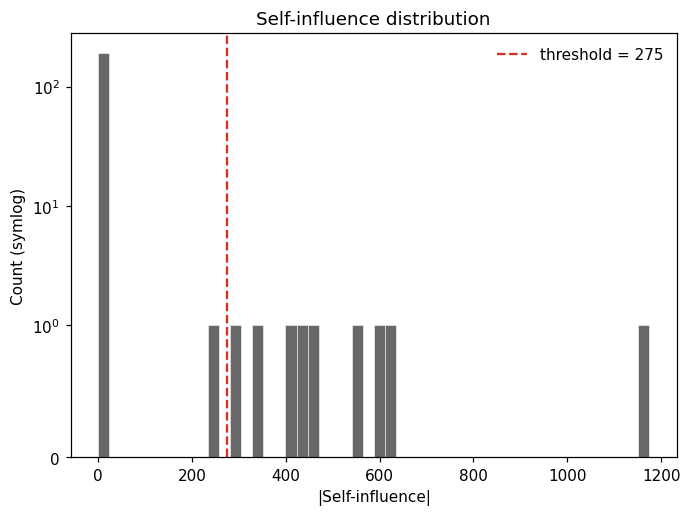

flagged by find_mislabeled:   [np.int64(123), np.int64(124), np.int64(132), np.int64(134), np.int64(136), np.int64(138), np.int64(139), np.int64(142), np.int64(146)]
ground-truth corrupted:       [np.int64(104), np.int64(123), np.int64(124), np.int64(132), np.int64(134), np.int64(136), np.int64(138), np.int64(139), np.int64(142), np.int64(146)]
recall:                       9 / 10
false positives:              0


In [4]:
self_inf = self_influence(attr)
fig, _ = viz.plot_self_influence(self_inf)
plt.show()

flagged = find_mislabeled(attr)
print(f'flagged by find_mislabeled:   {sorted(flagged)}')
print(f'ground-truth corrupted:       {sorted(corrupted)}')
print(f'recall:                       {len(set(flagged) & set(corrupted))} / {len(corrupted)}')
print(f'false positives:              {len(set(flagged) - set(corrupted))}')

When per-sample training error is also available, the *scatter* form is
more informative: an outlier with high self-influence **and** high error is a
much stronger candidate than one with high self-influence alone.

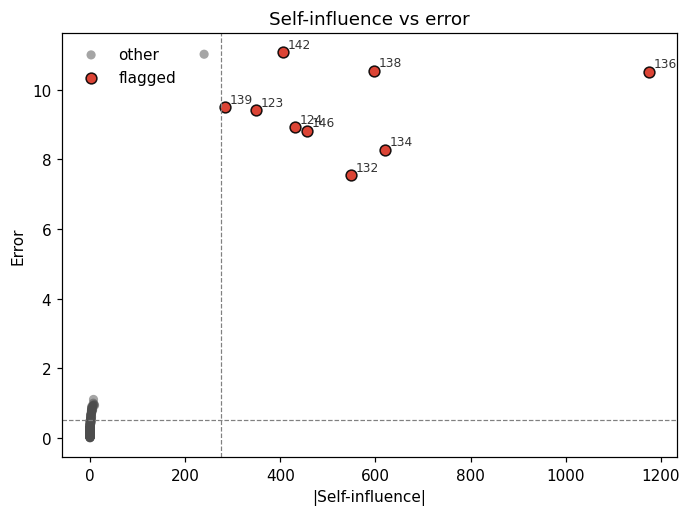

In [5]:
train_err = np.abs(model.predict(X_train) - y_train)
fig, _ = viz.plot_self_influence(self_inf, errors=train_err, annotate=True)
plt.show()

## 4. Explain one prediction: `plot_top_influencers`

For any single test point we can read off which training samples helped or
hurt that prediction. Pick a test point where the model is currently doing
badly:

worst test point: index 21, error 1.37


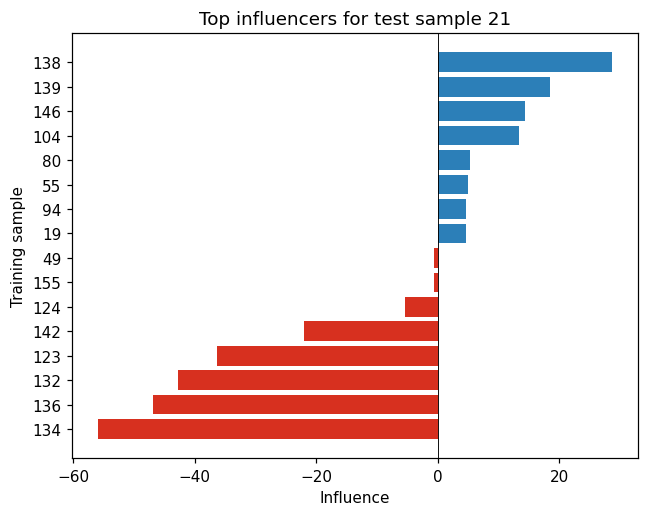

corrupted indices among the top-8 harmful: [np.int64(123), np.int64(124), np.int64(132), np.int64(134), np.int64(136), np.int64(142)]  (6/8)


In [6]:
test_err = np.abs(model.predict(X_test) - y_test)
worst_test = int(np.argmax(test_err))
print(f'worst test point: index {worst_test}, error {test_err[worst_test]:.2f}')

fig, _ = viz.plot_top_influencers(scores, test_idx=worst_test, k=8)
plt.show()

# Which of the top-8 harmful training points are actually corrupted?
worst_row = scores[worst_test]
harmful_top8 = np.argsort(worst_row)[:8]
hit = set(harmful_top8) & set(corrupted)
print(f'corrupted indices among the top-8 harmful: {sorted(hit)}  ({len(hit)}/8)')

## 5. Are the scores meaningful? `plot_removal_curve`

A canonical sanity-check: drop the top-k% of training points by influence,
refit, measure test loss. If influence is real, removing the harmful tail
should lower loss faster than random removal; removing the helpful tail
should raise it faster.

`removal_curve` does the refits for us. It returns a dict that goes straight
into `plot_removal_curve`.

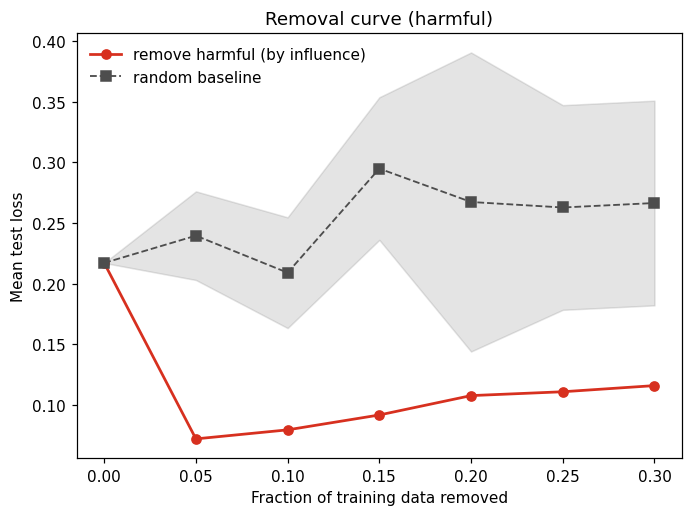

test loss at f=0.00:                  0.217
minimum after harmful-removal:        0.072
random baseline at same fraction:     0.240
loss reduction from removing harmful: 0.145


In [7]:
curve_h = removal_curve(
    attr, X_test, y_test,
    fractions=np.linspace(0.0, 0.3, 7),
    direction='harmful',
    n_random=5,
    random_state=0,
)
fig, _ = viz.plot_removal_curve(curve_h)
plt.show()

by_inf = curve_h['by_influence']
rand_m = curve_h['random_mean']
drop = by_inf[0] - by_inf.min()
print(f'test loss at f=0.00:                  {by_inf[0]:.3f}')
print(f'minimum after harmful-removal:        {by_inf.min():.3f}')
print(f'random baseline at same fraction:     {rand_m[by_inf.argmin()]:.3f}')
print(f'loss reduction from removing harmful: {drop:.3f}')

Inverting the direction — removing the *helpful* tail first — should hurt
the model dramatically. It does:

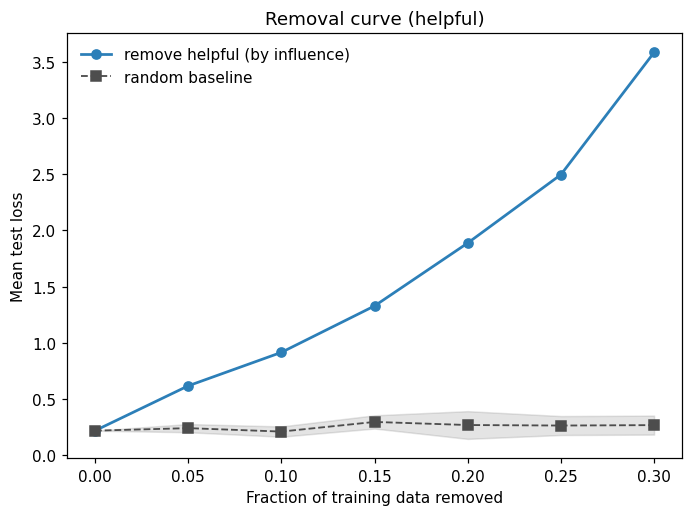

In [8]:
curve_p = removal_curve(
    attr, X_test, y_test,
    fractions=np.linspace(0.0, 0.3, 7),
    direction='helpful',
    n_random=5,
    random_state=0,
)
fig, _ = viz.plot_removal_curve(curve_p)
plt.show()

## 6. Audit a subgroup: `plot_by_group`

When the training data has a categorical structure (sources, demographics,
sites, batches), aggregating influence within group is a natural fairness /
QA view. Here the bug was concentrated in source `C`, and the per-group
aggregate confirms it.

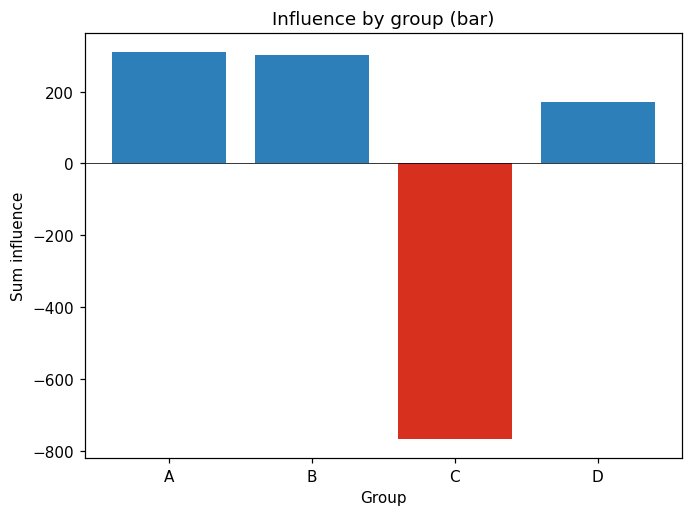

In [9]:
fig, _ = viz.plot_by_group(scores, sources, style='bar', method='sum')
plt.show()

The bar chart collapses each group to a single number. To inspect the
*spread* — does every sample in group C hurt, or only the corrupted ones? —
use the distribution styles. The corrupted points show up as the outliers
hanging off the bottom of C's box / violin.

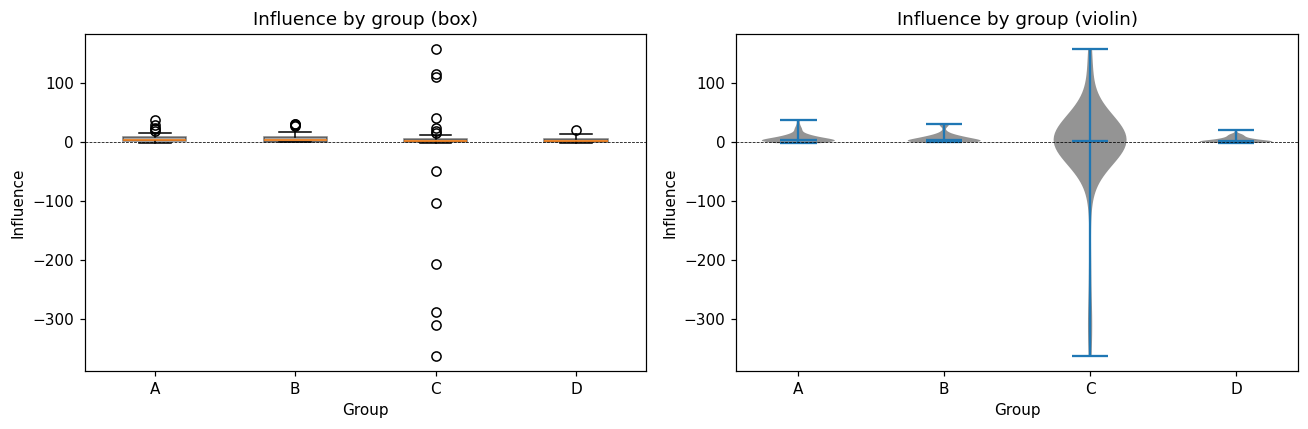

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
viz.plot_by_group(scores, sources, style='box', ax=axes[0])
viz.plot_by_group(scores, sources, style='violin', ax=axes[1])
plt.tight_layout()
plt.show()

## 7. Do methods agree? `plot_method_comparison`

`InfluenceFunctions` is an *infinitesimal* approximation; `LOOInfluence`
actually retrains the model without each point. They typically disagree in
absolute scale but largely agree on *ranking*. We restrict to a smaller
subproblem so LOO finishes in seconds.

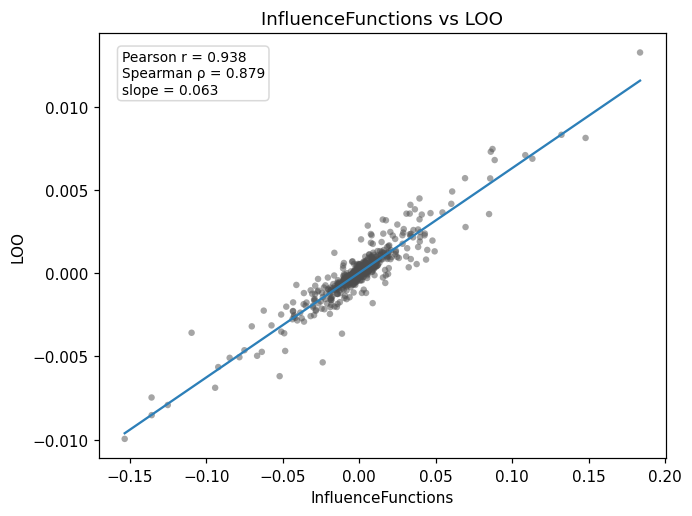

In [11]:
sub = 60
m_sub = Ridge(alpha=1.0).fit(X_train[:sub], y_train[:sub])
attr_if  = InfluenceFunctions(mode='loss', damping=1e-3).fit(m_sub, X_train[:sub], y_train[:sub])
attr_loo = LOOInfluence(mode='loss', n_jobs=-1, verbose=0).fit(m_sub, X_train[:sub], y_train[:sub])

s_if  = attr_if.explain(X_test[:15],  y_test[:15])
s_loo = attr_loo.explain(X_test[:15], y_test[:15])

fig, _ = viz.plot_method_comparison(s_if, s_loo, names=('InfluenceFunctions', 'LOO'))
plt.show()

## 8. Is the ranking stable? `plot_top_k_stability`

For noisy estimators (or as a robustness check) we rerun the attributor on
*resampled* training sets and ask: how often does each sample appear in the
top-`k`?

A sample that shows up in 10 of 12 replicates is a much more credible
"important point" than one that only sneaks in once.

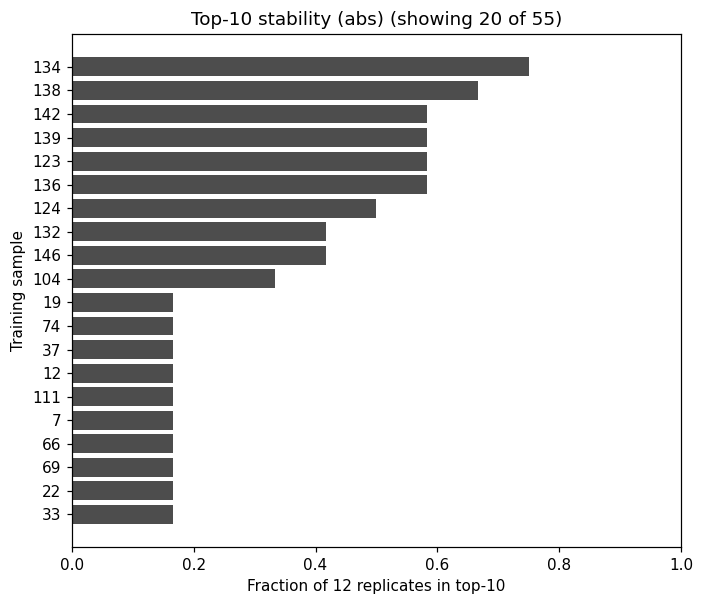

In [12]:
n_rep = 12
reps = np.zeros((n_rep, n_train))
for r in range(n_rep):
    boot = np.random.default_rng(100 + r).choice(n_train, size=n_train, replace=True)
    m_r  = Ridge(alpha=1.0).fit(X_train[boot], y_train[boot])
    a_r  = InfluenceFunctions(mode='loss', damping=1e-3).fit(m_r, X_train[boot], y_train[boot])
    s_r  = a_r.explain(X_test[:15], y_test[:15]).sum(axis=0)
    # Map back to original indices (with duplicates summing).
    np.add.at(reps[r], boot, s_r)

fig, _ = viz.plot_top_k_stability(reps, k=10, show='abs', max_show=20)
plt.show()

## 9. Cross-sample structure: `plot_heatmap`

For small problems the full influence matrix is worth a look. By default
the heatmap is restricted to the rows/columns carrying the most influence
mass so it remains readable as `n_train` grows.

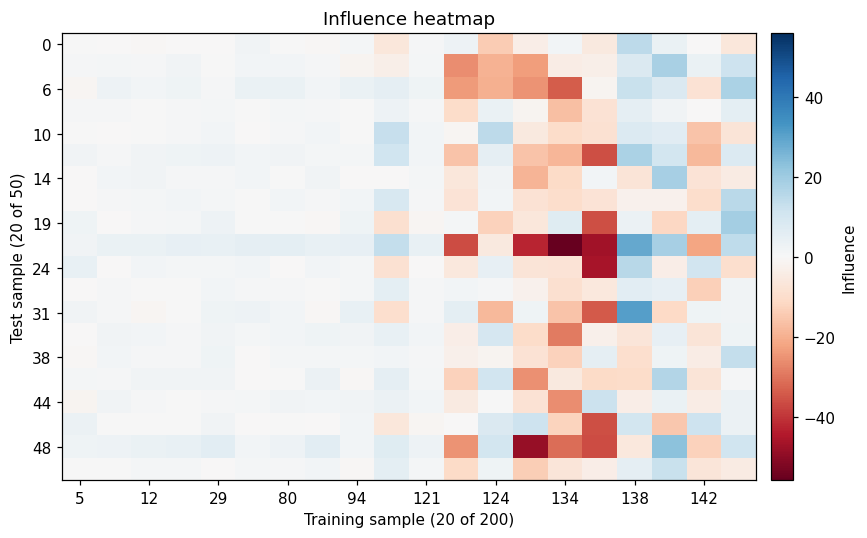

In [13]:
fig, _ = viz.plot_heatmap(scores, top_k=20)
plt.show()

Co-clustering reorders the heatmap into coherent blocks — useful when you
suspect there are sub-populations of test points sharing the same supporting
training samples.

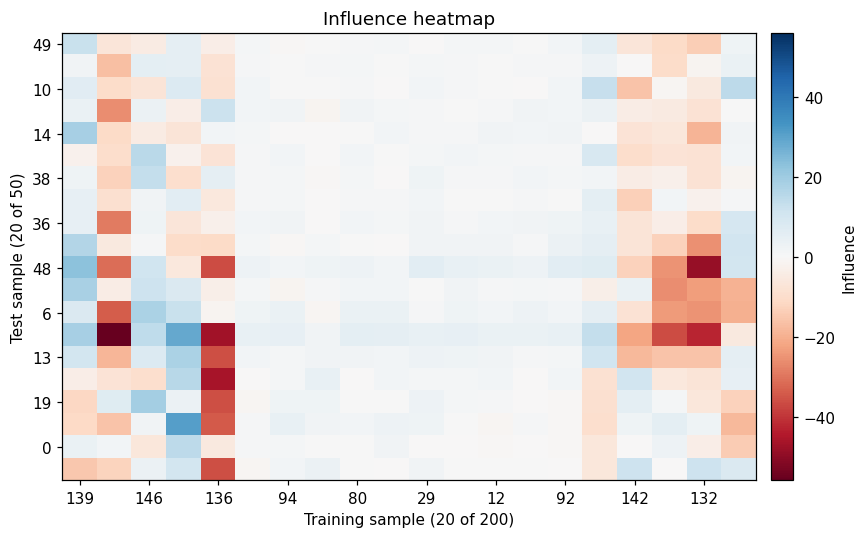

In [14]:
fig, _ = viz.plot_heatmap(scores, top_k=20, cluster=True)
plt.show()

## 10. Working with named samples

In real data, training samples have names — `patient_03A`, `cmpd_X1Y2`,
`batch_2024_07_11`. Every plot that shows per-sample tick labels accepts a
`labels=` argument (and `plot_heatmap` accepts `train_labels=` / `test_labels=`,
plumbed through `report()` as well).

Anything `np.asarray` understands works — a `list`, an `ndarray`, a pandas
`Index`, or a pandas `Series` (the same idiom: `labels=df.index`).

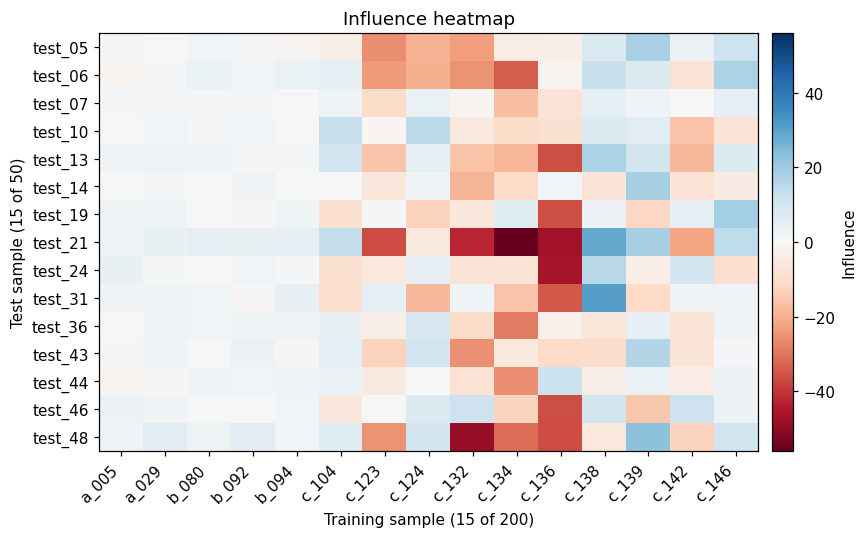

In [15]:
# Build readable labels of the form 'src_C_017' (source + row index).
train_labels = [f"{s.lower()}_{i:03d}" for i, s in enumerate(sources)]
test_labels  = [f"test_{i:02d}" for i in range(len(X_test))]

# Same heatmap as above, now self-describing on both axes.
fig, _ = viz.plot_heatmap(
    scores, top_k=15,
    train_labels=train_labels, test_labels=test_labels,
)
plt.show()

## 11. One-liner overview: `report`

`viz.report(attr, X_test, y_test, ...)` packs the four most useful panels
into a single figure. With `train_labels=` / `test_labels=`, the dashboard
is self-documenting against your real sample IDs.

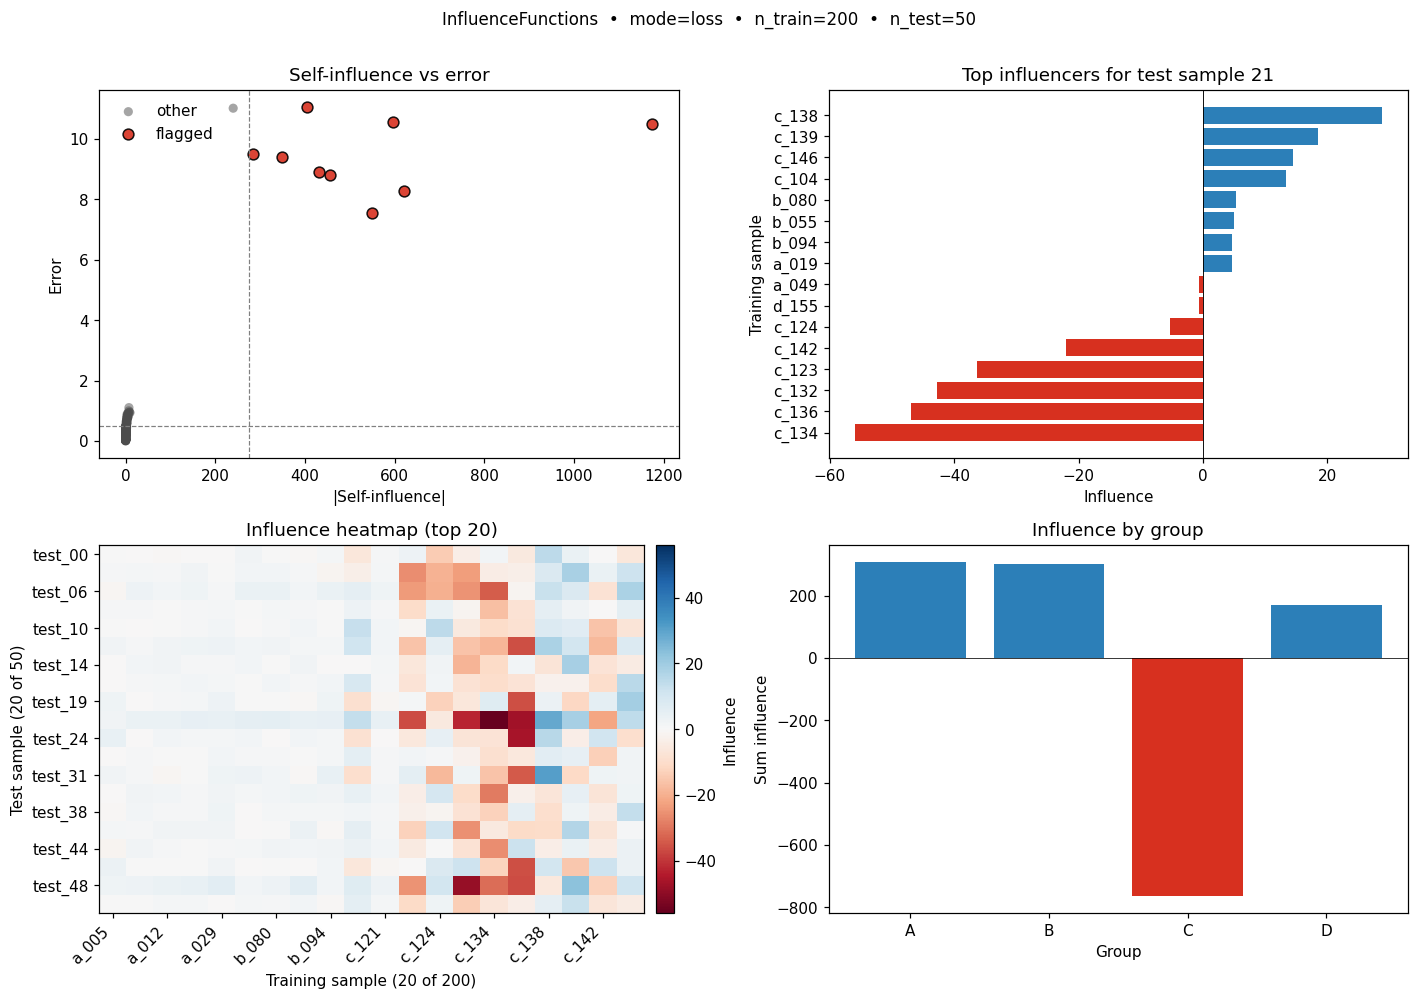

In [16]:
fig = viz.report(
    attr, X_test, y_test,
    groups=sources, errors=train_err,
    train_labels=train_labels, test_labels=test_labels,
    test_idx=worst_test, k=8, top_k=20,
)
plt.show()

## 12. Real data: breast-cancer classification

To check that the same diagnostic story works on a real dataset, we fit a
`LogisticRegression` on `sklearn.datasets.load_breast_cancer` after
deliberately flipping 10 training labels. The same `report()` call works
unchanged — the only differences are the model class and `mode='loss'` now
uses negative-log-likelihood.

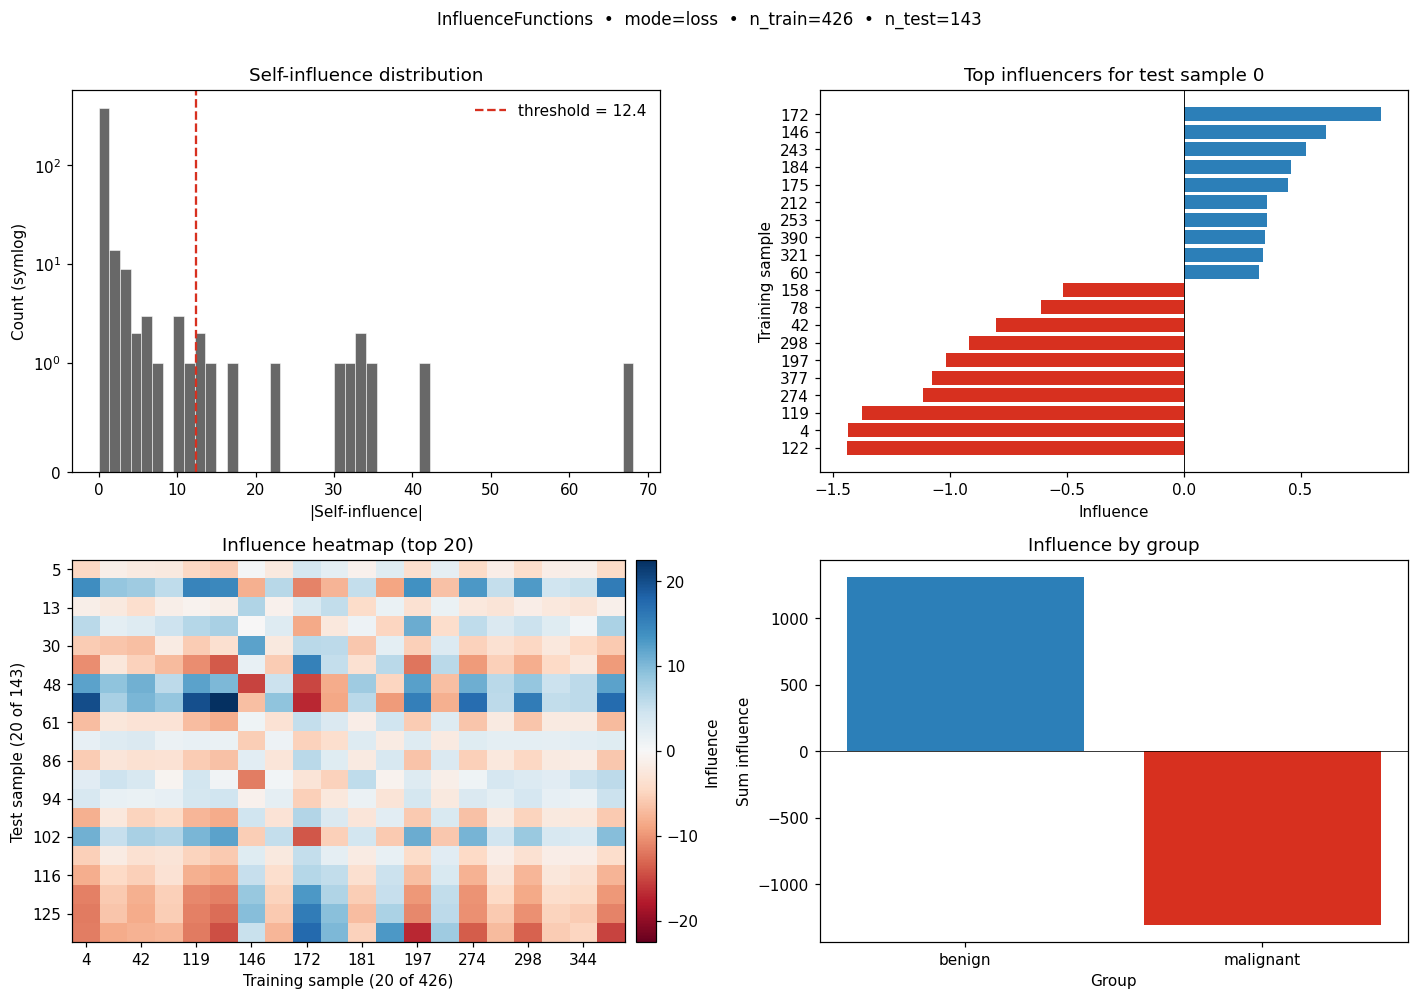

flipped labels recovered by find_mislabeled: 8 / 10


In [17]:
data = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    data.data, data.target, test_size=0.25, random_state=0, stratify=data.target,
)
scaler = StandardScaler().fit(Xb_tr)
Xb_tr_s = scaler.transform(Xb_tr)
Xb_te_s = scaler.transform(Xb_te)

flip = np.random.RandomState(1).choice(len(yb_tr), size=10, replace=False)
yb_tr_noisy = yb_tr.copy()
yb_tr_noisy[flip] = 1 - yb_tr_noisy[flip]

clf = LogisticRegression(C=1.0, max_iter=5000).fit(Xb_tr_s, yb_tr_noisy)
attr_b = InfluenceFunctions(mode='loss', damping=1e-3).fit(clf, Xb_tr_s, yb_tr_noisy)
classes = np.where(yb_tr_noisy == 1, 'benign', 'malignant')

fig = viz.report(attr_b, Xb_te_s, yb_te, groups=classes, test_idx=0, k=10, top_k=20)
plt.show()

flagged_b = find_mislabeled(attr_b)
hit_b = set(flagged_b) & set(flip)
print(f'flipped labels recovered by find_mislabeled: {len(hit_b)} / {len(flip)}')

## Where to go next

- `pyinfluence.influence(...)` is a high-level one-shot that picks the right
  attributor for your model.
- For model-agnostic but expensive estimates: `LOOInfluence` or
  `BootstrapInfluence`.
- Run `removal_curve` whenever you're not sure if your influence scores mean
  anything — it's the closest thing to a falsification test the field has.